In [1]:
# Core
import json
import numpy as np
import pandas as pd
import joblib

# Visualization (unchanged)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import optuna

/e/conda/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
scaler = joblib.load("../data/processed/X_scaler.pkl")
X_train = np.load("../data/processed/X_train.npy")
X_val = np.load("../data/processed/X_val.npy")
X_test = np.load("../data/processed/X_test.npy")
X_trainVal = np.load("../data/processed/X_trainVal.npy")

y_train = np.load("../data/processed/y_train.npy")
y_val = np.load("../data/processed/y_val.npy")
y_test = np.load("../data/processed/y_test.npy")
y_trainVal = np.load("../data/processed/y_trainVal.npy")
y_scaler = joblib.load("../data/processed/y_scaler.pkl")

with open("../data/processed/feature_names.json", "r") as f:
    feature_names = json.load(f)

In [3]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 100)

ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_trainVal, y_trainVal)

print("Best alpha:", ridge.alpha_)

Best alpha: 45.34878508128591


In [6]:
from sklearn.linear_model import Ridge
final_ridge = Ridge(alpha=ridge.alpha_)
final_ridge.fit(X_trainVal, y_trainVal)

ridge_preds_raw = final_ridge.predict(X_test)
ridge_preds = y_scaler.inverse_transform(ridge_preds_raw)

mse = mean_squared_error(y_test, ridge_preds)
r2 = r2_score(y_test, ridge_preds)

print(f"Ridge Test MSE: {mse:.4f}")
print(f"Ridge R2: {r2:.4f}")

Ridge Test MSE: 75.2427
Ridge R2: 0.1335


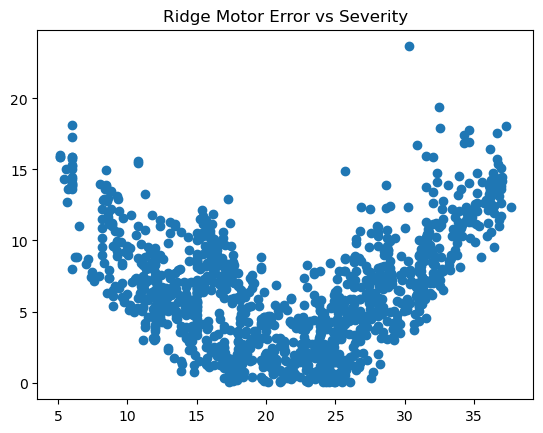

In [7]:
abs_errors = np.abs(y_test - ridge_preds)

plt.scatter(y_test[:,0], abs_errors[:,0])
plt.title("Ridge Motor Error vs Severity")
plt.show()

In [9]:
from sklearn.linear_model import MultiTaskElasticNetCV

enet = MultiTaskElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
    alphas=np.logspace(-3, 2, 40),  # remove 1e-4
    cv=5,
    max_iter=5000,
    tol=1e-3,
    n_jobs=-1
)

enet.fit(X_trainVal, y_trainVal)

,"l1_ratio l1_ratio: float or list of float, default=0.5The ElasticNet mixing parameter, with 0 < l1_ratio <= 1.For l1_ratio = 1 the penalty is an L1/L2 penalty. For l1_ratio = 0 itis an L2 penalty.For ``0 < l1_ratio < 1``, the penalty is a combination of L1/L2 and L2.This parameter can be a list, in which case the differentvalues are tested by cross-validation and the one giving the bestprediction score is used. Note that a good choice of list ofvalues for l1_ratio is often to put more values close to 1(i.e. Lasso) and less close to 0 (i.e. Ridge), as in ``[.1, .5, .7,.9, .95, .99, 1]``.","[0.1, 0.3, ...]"
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path, used for each l1_ratio.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",array([1.0000...00000000e+02])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",5000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.001
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"verbose verbose: bool or int, default=0Amount of verbosity.",0
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation. Note that this isused only if multiple values for l1_ratio are given.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [10]:
enet_preds_raw = enet.predict(X_test)
enet_preds = y_scaler.inverse_transform(enet_preds_raw)
enet_mse = mean_squared_error(y_test, enet_preds)
enet_r2 = r2_score(y_test, enet_preds)

print(f"ElasticNet Test MSE: {enet_mse:.4f}")
print(f"ElasticNet R2: {enet_r2:.4f}")


ElasticNet Test MSE: 75.2605
ElasticNet R2: 0.1331


In [11]:
import joblib

joblib.dump(final_ridge, "../models/ridge_expert.pkl")
joblib.dump(enet, "../models/enet_expert.pkl")

print("✅ Linear experts frozen.")

✅ Linear experts frozen.
